# Novel Sound and Loudness Analysis — Violence/Scariness

Tests whether **character sound loudness standard deviation** correlates with violent/scary scenes in automatically annotated fiction TEI XML.

### Violence/Scariness assessment scale
| Value | Meaning |
|---|---|
| 0 | Absent — no violent or scary content |
| 1 | Weak — mild tension / mild violence |
| 2 | Strong — explicit violence or high-fear content |

### Schema assumptions
- One XML file per novel in `violence_annotated/`
- `<violence assessment="N">` wraps `<scene n="N">`
- `<character_sound loudness="N.N">` inside `<scene>`
- `<ambient_sound loudness="N.N">` inside `<scene>` (optional, extracted but not primary)
- Sound elements **without** `@loudness` are skipped

### Outputs
- `output/scene_data_char_violence.csv` — one row per scene, all features
- `output/results_summary_char_violence.txt` — full statistical results
- `output/plots/` — violin plots, ROC curve, per-novel boxplot


## 0. Install dependencies
Run once if any packages are missing.

In [ ]:
#!pip install lxml scipy statsmodels scikit-learn matplotlib seaborn pandas numpy

## 1. Imports

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from lxml import etree

from scipy import stats
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## 2. Configuration

**Edit the paths and threshold here before running the rest of the notebook.**

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────

INPUT_DIR  = Path("/Users/sguhr/Library/Mobile Documents/com~apple~CloudDocs/20250701_Backup_MacBook/UC Berkeley/2025:26/NLP4DH/violence_annotated")
OUTPUT_DIR = Path("/Users/sguhr/Library/Mobile Documents/com~apple~CloudDocs/20250701_Backup_MacBook/UC Berkeley/2025:26/NLP4DH/results_violence-sound-correlation_analysis")
PLOTS_DIR  = Path("/Users/sguhr/Library/Mobile Documents/com~apple~CloudDocs/20250701_Backup_MacBook/UC Berkeley/2025:26/NLP4DH/results_violence-sound-correlation_analysis/plots")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Violence/Scariness assessment scale ────────────────────────────────────
#   0 = absent   (no violent or scary content)
#   1 = weak     (mild tension / mild violence)
#   2 = strong   (explicit violence or high-fear content)
#
# VIOLENCE_THRESHOLD controls which scenes count as violent/scary:
#   1  →  weak AND strong scenes (recommended default)
#   2  →  only strong scenes (stricter, smaller positive class)
VIOLENCE_THRESHOLD = 1

# TEI namespace — the parser retries without it automatically if needed
NS = {"tei": "http://www.tei-c.org/ns/1.0"}

print(f"Input  : {INPUT_DIR.resolve()}")
print(f"Output : {OUTPUT_DIR.resolve()}")
print(f"Violence threshold : violence assessment >= {VIOLENCE_THRESHOLD} "
      f"({'weak+strong' if VIOLENCE_THRESHOLD == 1 else 'strong only'})")

## 3. Helper functions

In [ ]:
def tei_find(element, xpath, ns=NS):
    """XPath search that works with or without the TEI namespace prefix."""
    try:
        results = element.xpath(xpath, namespaces=ns)
        if not results:
            results = element.xpath(re.sub(r'tei:', '', xpath))
        return results
    except etree.XPathEvalError:
        return []


def extract_loudness_values(scene_el, sound_tag):
    """Return list of float loudness values for a given sound element tag.
    Elements without @loudness are silently skipped."""
    sounds = tei_find(scene_el, f".//tei:{sound_tag}[@loudness]")
    values = []
    for s in sounds:
        try:
            values.append(float(s.get("loudness")))
        except (TypeError, ValueError):
            pass
    return values


def scene_stats(loudness_values):
    """Compute descriptive statistics for a list of loudness values.
    Returns NaN for all stats when fewer than 2 values are present."""
    if len(loudness_values) < 2:
        return dict(n=len(loudness_values),
                    mean=float('nan'), std=float('nan'), median=float('nan'),
                    iqr=float('nan'), vrange=float('nan'), min=float('nan'), max=float('nan'))
    arr = np.array(loudness_values)
    return dict(
        n      = len(arr),
        mean   = arr.mean(),
        std    = arr.std(ddof=1),
        median = float(np.median(arr)),
        iqr    = float(np.percentile(arr, 75) - np.percentile(arr, 25)),
        vrange = float(arr.max() - arr.min()),
        min    = float(arr.min()),
        max    = float(arr.max()),
    )

print("Helper functions defined.")

Helper functions defined.


## 4. Parse all novels

In [ ]:
def parse_novel(xml_path):
    """Parse one TEI XML file; return a list of dicts, one per scene."""
    novel_id = xml_path.stem
    tree     = etree.parse(str(xml_path))
    root     = tree.getroot()
    records  = []

    violence_elements = (tei_find(root, ".//tei:violence") or
                         tei_find(root, ".//violence"))

    for violence_el in violence_elements:
        try:
            violence_score = int(violence_el.get("assessment", 0))
        except (TypeError, ValueError):
            violence_score = 0

        violence_label = {0: "absent", 1: "weak", 2: "strong"}.get(violence_score, "unknown")
        is_violent     = int(violence_score >= VIOLENCE_THRESHOLD)

        scenes = (tei_find(violence_el, ".//tei:scene") or
                  tei_find(violence_el, ".//scene"))

        for scene_el in scenes:
            scene_n    = scene_el.get("n", "?")
            char_vals  = extract_loudness_values(scene_el, "character_sound")
            char_st    = scene_stats(char_vals)
            amb_vals   = extract_loudness_values(scene_el, "ambient_sound")
            amb_st     = scene_stats(amb_vals)
            word_count = len(etree.tostring(scene_el,
                             method="text", encoding="unicode").split())

            records.append(dict(
                novel_id        = novel_id,
                scene_n         = scene_n,
                violence_score  = violence_score,
                violence_label  = violence_label,
                is_violent      = is_violent,
                word_count      = word_count,
                # character sound (PRIMARY)
                char_n          = char_st["n"],
                char_mean       = char_st["mean"],
                char_std        = char_st["std"],
                char_median     = char_st["median"],
                char_iqr        = char_st["iqr"],
                char_range      = char_st["vrange"],
                char_min        = char_st["min"],
                char_max        = char_st["max"],
                # ambient sound (secondary, kept for completeness)
                amb_n           = amb_st["n"],
                amb_mean        = amb_st["mean"],
                amb_std         = amb_st["std"],
                amb_median      = amb_st["median"],
                amb_iqr         = amb_st["iqr"],
                amb_range       = amb_st["vrange"],
            ))
    return records


# ── Run extraction ────────────────────────────────────────────────────────
xml_files = sorted(INPUT_DIR.glob("*.xml"))

if not xml_files:
    raise FileNotFoundError(
        f"No XML files found in '{INPUT_DIR}'. "
        "Place your 10 TEI files there and re-run this cell.")

all_records = []
for f in xml_files:
    print(f"Parsing {f.name} …")
    all_records.extend(parse_novel(f))

df = pd.DataFrame(all_records)
df.to_csv(OUTPUT_DIR / "scene_data_char_violence.csv", index=False)

print(f"\nTotal scenes extracted : {len(df)}")
print(df["violence_label"].value_counts().to_string())
df.head()

Parsing Cowboy_Be_Mine_TEXAS.xml …
Parsing Deceptions-CALIFORNIA.xml …
Parsing Finders_Keepers_VERMONT.xml …
Parsing Found_His_Perfect_Wife_ALASKA.xml …
Parsing Love_by_Proxy_ILLINOIS.xml …
Parsing Midnight_Wishes_WYOMING.xml …
Parsing Pros_and_Cons_MASSACHUSETTS.xml …
Parsing Tangled_Lies_HAWAII.xml …
Parsing Too_Near_the_Fire_OHIO.xml …
Parsing Warriors_Embrace_MISSISSIPPI.xml …

Total scenes extracted : 815
violence_label
absent    753
weak       36
strong     26


,novel_id,scene_n,violence_score,violence_label,is_violent,word_count,char_n,char_mean,char_std,char_median,char_iqr,char_range,char_min,char_max,amb_n,amb_mean,amb_std,amb_median,amb_iqr,amb_range
0,Cowboy_Be_Mine_TEXAS,1,0,absent,0,702,3,2.666667,0.577350,3.0,0.5,1.0,2.0,3.0,0,NaN,NaN,NaN,NaN,NaN
1,Cowboy_Be_Mine_TEXAS,2,0,absent,0,480,5,3.000000,0.000000,3.0,0.0,0.0,3.0,3.0,0,NaN,NaN,NaN,NaN,NaN
2,Cowboy_Be_Mine_TEXAS,3,0,absent,0,1325,11,3.045455,0.350325,3.0,0.0,1.5,2.5,4.0,1,NaN,NaN,NaN,NaN,NaN
3,Cowboy_Be_Mine_TEXAS,4,0,absent,0,635,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4.0,0.0,4.0,0.0,0.0
4,Cowboy_Be_Mine_TEXAS,5,0,absent,0,464,3,3.666667,0.577350,4.0,0.5,1.0,3.0,4.0,1,NaN,NaN,NaN,NaN,NaN


## 5. Prepare analysis subset

Restrict to scenes with **≥ 2 character sound events** (standard deviation is undefined for fewer than 2 values).


In [ ]:
df_valid = df[df["char_n"] >= 2].copy()

# Ordered categorical for violence label (used in plots)
df_valid["violence_label"] = pd.Categorical(
    df_valid["violence_label"],
    categories=["absent", "weak", "strong"],
    ordered=True
)

violent_mask     = df_valid["is_violent"] == 1
non_violent_mask = df_valid["is_violent"] == 0

print(f"Scenes with >= 2 character sound events : {len(df_valid)}")
print(f"  Absent  (score 0) : {(df_valid['violence_score']==0).sum()}")
print(f"  Weak    (score 1) : {(df_valid['violence_score']==1).sum()}")
print(f"  Strong  (score 2) : {(df_valid['violence_score']==2).sum()}")
print(f"  ── Violent total (>= {VIOLENCE_THRESHOLD}) : {violent_mask.sum()}")
print(f"  ── Non-violent        : {non_violent_mask.sum()}")

Scenes with >= 2 character sound events : 588
  Absent  (score 0) : 556
  Weak    (score 1) : 13
  Strong  (score 2) : 19
  ── Violent total (>= 1) : 32
  ── Non-violent        : 556


## 6. Descriptive statistics

In [ ]:
# ── By binary violent label ───────────────────────────────────────────────
print("Character sound std  —  by scene type")
print("=" * 45)
for label, mask in [("Non-violent (absent)", non_violent_mask),
                    ("Violent/Scary (weak+strong)", violent_mask)]:
    s = df_valid.loc[mask, "char_std"].dropna()
    print(f"\n{label}  (n={len(s)})")
    print(f"  Mean   : {s.mean():.3f}")
    print(f"  Median : {s.median():.3f}")
    print(f"  SD     : {s.std():.3f}")
    print(f"  Range  : {s.min():.3f} – {s.max():.3f}")

print()
print("Character sound std  —  by violence score (0 / 1 / 2)")
print("=" * 45)
print(df_valid.groupby("violence_score")["char_std"]
      .agg(["count", "mean", "median", "std"])
      .rename(columns={"count":"n", "mean":"mean_std",
                       "median":"median_std", "std":"sd_of_std"})
      .round(3)
      .to_string())

Character sound std  —  by scene type

Non-violent (absent)  (n=556)
  Mean   : 0.511
  Median : 0.500
  SD     : 0.339
  Range  : 0.000 – 1.500

Violent/Scary (weak+strong)  (n=32)
  Mean   : 0.749
  Median : 0.728
  SD     : 0.512
  Range  : 0.000 – 2.121

Character sound std  —  by violence score (0 / 1 / 2)
                  n  mean_std  median_std  sd_of_std
violence_score                                      
0               556     0.511       0.500      0.339
1                13     0.554       0.408      0.564
2                19     0.883       0.913      0.439


## 7. Statistical tests

In [ ]:
violent_std     = df_valid.loc[violent_mask,     "char_std"].dropna()
non_violent_std = df_valid.loc[non_violent_mask, "char_std"].dropna()
results_lines   = []

def log(msg=""):
    print(msg)
    results_lines.append(msg)

# ── 1. Mann-Whitney U (primary test) ──────────────────────────────────────
log("1. MANN-WHITNEY U TEST")
log("   H1: violent/scary scenes have higher char_std than non-violent")
log("-" * 55)
if len(violent_std) > 0 and len(non_violent_std) > 0:
    u_stat, p_val = mannwhitneyu(violent_std, non_violent_std, alternative="greater")
    n1, n2 = len(violent_std), len(non_violent_std)
    r_rb   = 1 - (2 * u_stat) / (n1 * n2)
    log(f"   U = {u_stat:.1f}")
    log(f"   p = {p_val:.4f}  (one-tailed)")
    log(f"   Rank-biserial r = {r_rb:.3f}  (effect size)")
    log(f"   → {'Significant' if p_val < 0.05 else 'Not significant'} at α = 0.05")
else:
    log("   Insufficient data.")

log()

# ── 2. Point-biserial correlation ─────────────────────────────────────────
log("2. POINT-BISERIAL CORRELATION  (char_std ~ is_violent)")
log("-" * 55)
pb_data = df_valid[["char_std", "is_violent"]].dropna()
if len(pb_data) > 3:
    r_pb, p_pb = pointbiserialr(pb_data["is_violent"], pb_data["char_std"])
    log(f"   r_pb = {r_pb:.3f},  p = {p_pb:.4f}")
else:
    log("   Insufficient data.")

log()

# ── 3. Spearman rho (ordinal violence score 0/1/2) ────────────────────────
log("3. SPEARMAN CORRELATION  (char_std ~ violence_score ordinal 0/1/2)")
log("-" * 55)
sp_data = df_valid[["char_std", "violence_score"]].dropna()
if len(sp_data) > 3:
    rho, p_rho = stats.spearmanr(sp_data["char_std"], sp_data["violence_score"])
    log(f"   Spearman ρ = {rho:.3f},  p = {p_rho:.4f}")
else:
    log("   Insufficient data.")

log()

# ── 4. ROC / AUC ──────────────────────────────────────────────────────────
log("4. ROC / AUC  (char_std as predictor of violent/scary label)")
log("-" * 55)
roc_data = df_valid[["char_std", "is_violent"]].dropna()
auc = None
if roc_data["is_violent"].nunique() == 2 and len(roc_data) >= 5:
    auc = roc_auc_score(roc_data["is_violent"], roc_data["char_std"])
    log(f"   AUC = {auc:.3f}  (0.5 = chance, 1.0 = perfect)")
    log(f"   → char_std is {'better than' if auc > 0.5 else 'no better than'} "
        f"chance at discriminating violent/scary scenes")
else:
    log("   Insufficient class variation for ROC.")

# ── Save results ──────────────────────────────────────────────────────────
results_path = OUTPUT_DIR / "results_summary_char_violence.txt"
with open(results_path, "w", encoding="utf-8") as f:
    f.write("\n".join(results_lines))
print(f"\nResults saved to {results_path}")

1. MANN-WHITNEY U TEST
   H1: violent/scary scenes have higher char_std than non-violent
-------------------------------------------------------
   U = 11333.5
   p = 0.0044  (one-tailed)
   Rank-biserial r = -0.274  (effect size)
   → Significant at α = 0.05

2. POINT-BISERIAL CORRELATION  (char_std ~ is_violent)
-------------------------------------------------------
   r_pb = 0.153,  p = 0.0002

3. SPEARMAN CORRELATION  (char_std ~ violence_score ordinal 0/1/2)
-------------------------------------------------------
   Spearman ρ = 0.111,  p = 0.0070

4. ROC / AUC  (char_std as predictor of violent/scary label)
-------------------------------------------------------
   AUC = 0.637  (0.5 = chance, 1.0 = perfect)
   → char_std is better than chance at discriminating violent/scary scenes

Results saved to /Users/sguhr/Library/Mobile Documents/com~apple~CloudDocs/20250701_Backup_MacBook/UC Berkeley/2025:26/NLP4DH/results_violence-sound-correlation_analysis/results_summary_char_violence.

## 8. Plots

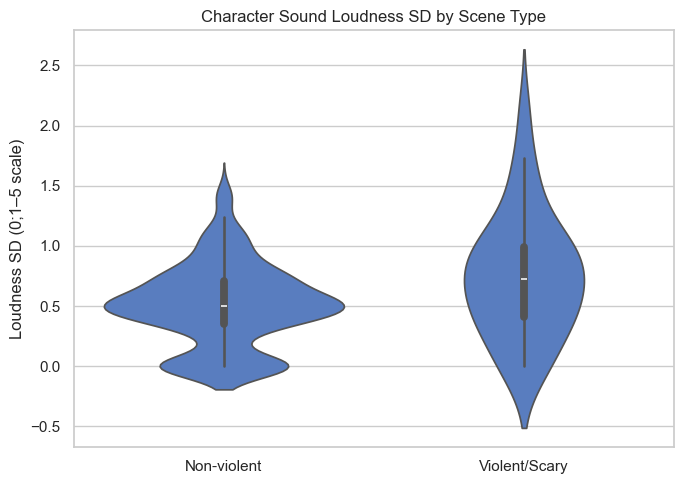

Saved violin_char_std_violence.png


In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

# ── 8a. Violin: char_std by binary scene type ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = df_valid.dropna(subset=["char_std"]).copy()
plot_df["Scene type"] = plot_df["is_violent"].map({0: "Non-violent", 1: "Violent/Scary"})
sns.violinplot(data=plot_df, x="Scene type", y="char_std",
               order=["Non-violent", "Violent/Scary"], inner="box", ax=ax)
ax.set_title("Character Sound Loudness SD by Scene Type")
ax.set_ylabel("Loudness SD (0;1–5 scale)")
ax.set_xlabel("")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_violin_char_std_violence.png", dpi=150)
plt.show()
print("Saved violin_char_std_violence.png")

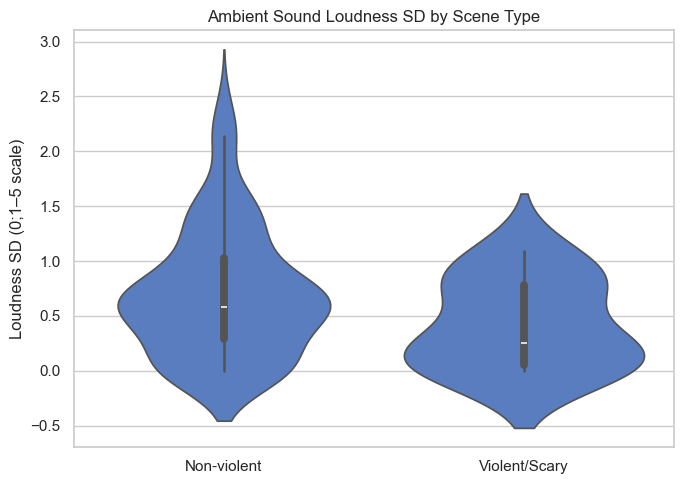

Saved violin_amb_std_violence.png


In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

# ── 8a. Violin: char_std by binary scene type ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = df_valid.dropna(subset=["amb_std"]).copy()
plot_df["Scene type"] = plot_df["is_violent"].map({0: "Non-violent", 1: "Violent/Scary"})
sns.violinplot(data=plot_df, x="Scene type", y="amb_std",
               order=["Non-violent", "Violent/Scary"], inner="box", ax=ax)
ax.set_title("Ambient Sound Loudness SD by Scene Type")
ax.set_ylabel("Loudness SD (0;1–5 scale)")
ax.set_xlabel("")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_violin_amb_std_violence.png", dpi=150)
plt.show()
print("Saved violin_amb_std_violence.png")

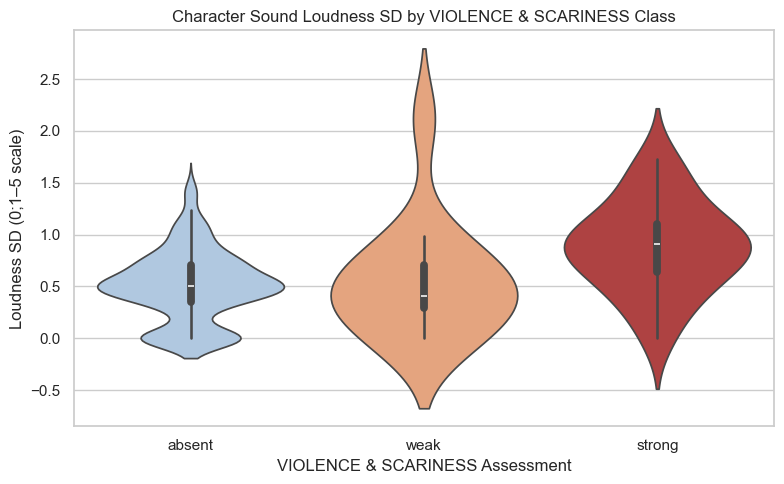

Saved violin_char_std_by_violence_class.png


In [ ]:
# ── 8b. Violin: char_std across all three violence classes (0 / 1 / 2) ────
fig, ax = plt.subplots(figsize=(8, 5))
label_order = ["absent", "weak", "strong"]
palette     = {"absent": "#a8c8e8", "weak": "#f5a06e", "strong": "#c03030"}
sns.violinplot(data=plot_df, x="violence_label", y="char_std",
               order=label_order, palette=palette, inner="box", ax=ax)
ax.set_title("Character Sound Loudness SD by VIOLENCE & SCARINESS Class")
ax.set_ylabel("Loudness SD (0;1–5 scale)")
ax.set_xlabel("VIOLENCE & SCARINESS Assessment")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_violin_char_std_by_violence_class.png", dpi=150)
plt.show()
print("Saved violin_char_std_by_violence_class.png")

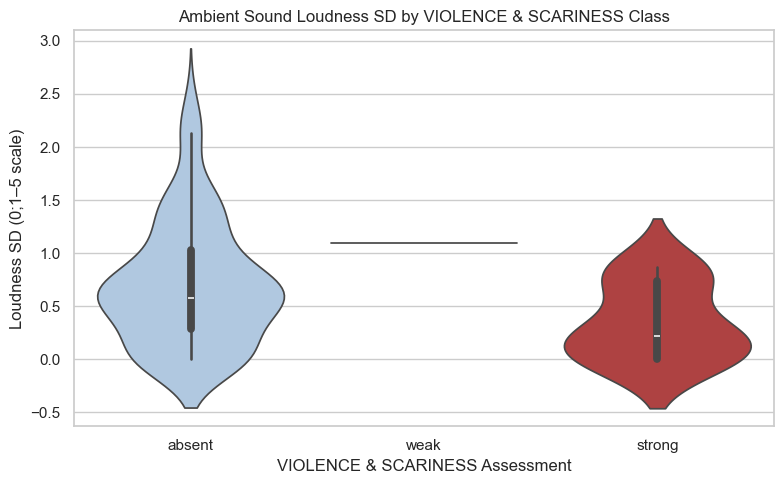

Saved violin_amb_std_by_violence_class.png


In [ ]:
# ── 8b. Violin: char_std across all three violence classes (0 / 1 / 2) ────
fig, ax = plt.subplots(figsize=(8, 5))
label_order = ["absent", "weak", "strong"]
palette     = {"absent": "#a8c8e8", "weak": "#f5a06e", "strong": "#c03030"}
sns.violinplot(data=plot_df, x="violence_label", y="amb_std",
               order=label_order, palette=palette, inner="box", ax=ax)
ax.set_title("Ambient Sound Loudness SD by VIOLENCE & SCARINESS Class")
ax.set_ylabel("Loudness SD (0;1–5 scale)")
ax.set_xlabel("VIOLENCE & SCARINESS Assessment")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_violin_amb_std_by_violence_class.png", dpi=150)
plt.show()
print("Saved violin_amb_std_by_violence_class.png")

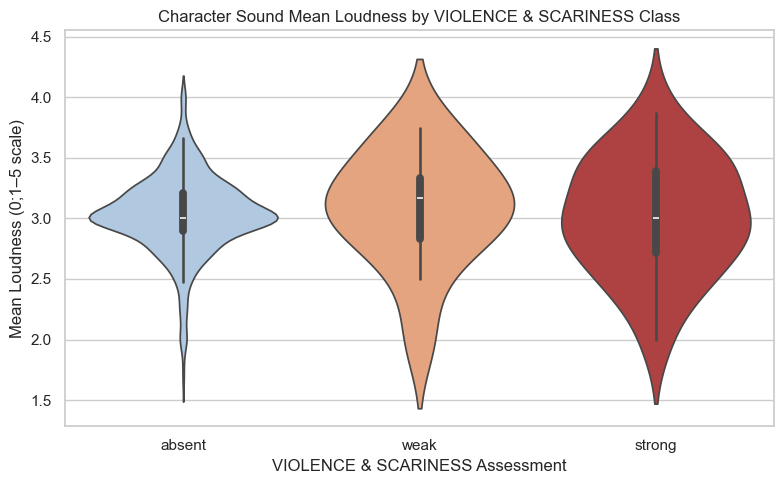

Saved violin_char_mean_by_violence_class.png


In [ ]:
# ── 8c. Violin: char_mean across violence classes ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=plot_df, x="violence_label", y="char_mean",
               order=label_order, palette=palette, inner="box", ax=ax)
ax.set_title("Character Sound Mean Loudness by VIOLENCE & SCARINESS Class")
ax.set_ylabel("Mean Loudness (0;1–5 scale)")
ax.set_xlabel("VIOLENCE & SCARINESS Assessment")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_violin_char_mean_by_violence_class.png", dpi=150)
plt.show()
print("Saved violin_char_mean_by_violence_class.png")

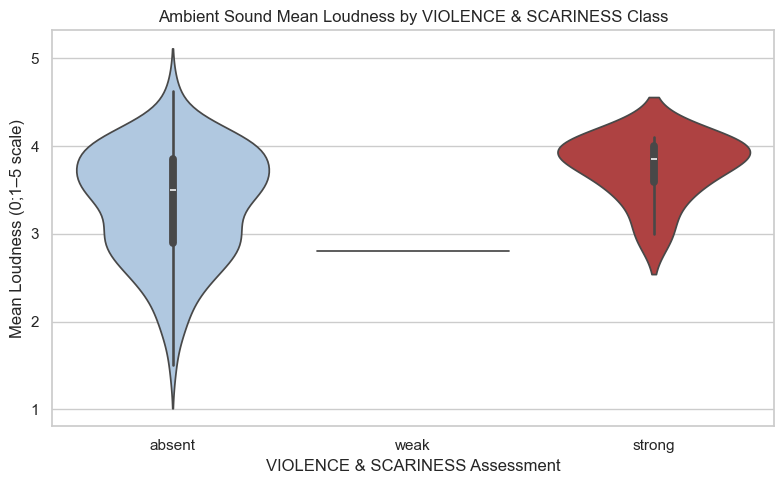

Saved violin_amb_mean_by_violence_class.png


In [ ]:
# ── 8c. Violin: char_mean across violence classes ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=plot_df, x="violence_label", y="amb_mean",
               order=label_order, palette=palette, inner="box", ax=ax)
ax.set_title("Ambient Sound Mean Loudness by VIOLENCE & SCARINESS Class")
ax.set_ylabel("Mean Loudness (0;1–5 scale)")
ax.set_xlabel("VIOLENCE & SCARINESS Assessment")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_violin_amb_mean_by_violence_class.png", dpi=150)
plt.show()
print("Saved violin_amb_mean_by_violence_class.png")

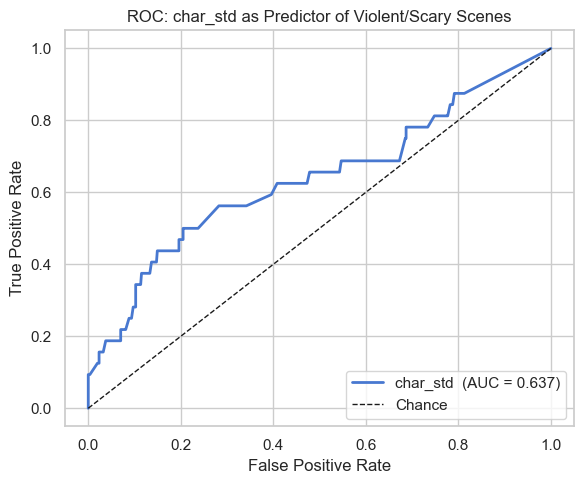

Saved roc_curve_char_violence.png


In [ ]:
# ── 8d. ROC curve ─────────────────────────────────────────────────────────
if auc is not None:
    fpr, tpr, _ = roc_curve(roc_data["is_violent"], roc_data["char_std"])
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, label=f"char_std  (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC: char_std as Predictor of Violent/Scary Scenes")
    ax.legend(loc="lower right")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "roc_curve_char_violence.png", dpi=150)
    plt.show()
    print("Saved roc_curve_char_violence.png")
else:
    print("ROC skipped — insufficient class variation.")

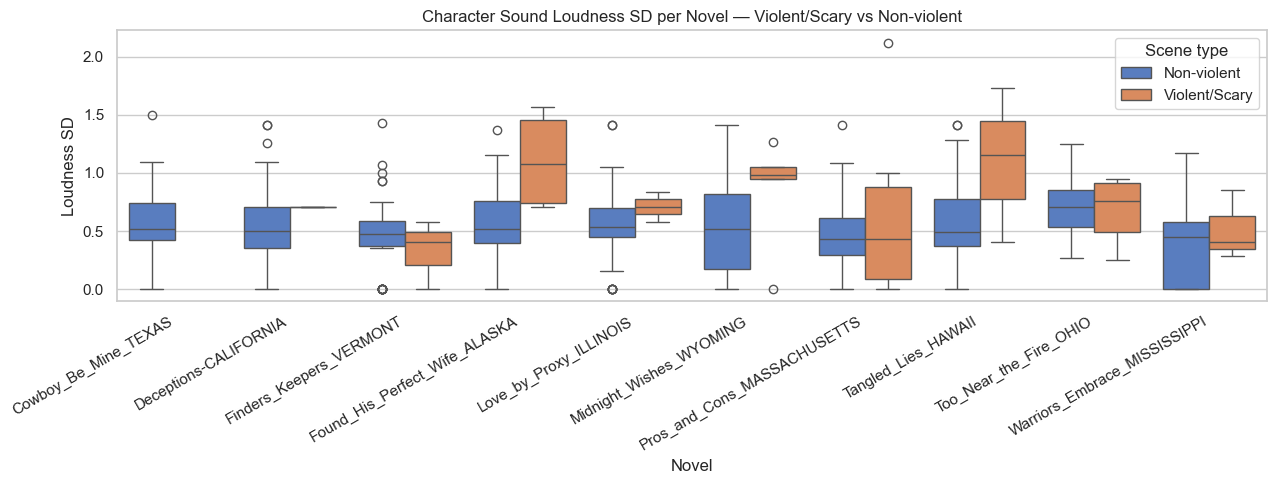

Saved boxplot_char_per_novel_violence.png


In [ ]:
# ── 8e. Per-novel boxplot of char_std ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
novel_order = sorted(plot_df["novel_id"].unique())
sns.boxplot(data=plot_df, x="novel_id", y="char_std",
            hue="Scene type", order=novel_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("Character Sound Loudness SD per Novel — Violent/Scary vs Non-violent")
ax.set_xlabel("Novel")
ax.set_ylabel("Loudness SD")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_boxplot_char_per_novel_violence.png", dpi=150)
plt.show()
print("Saved boxplot_char_per_novel_violence.png")

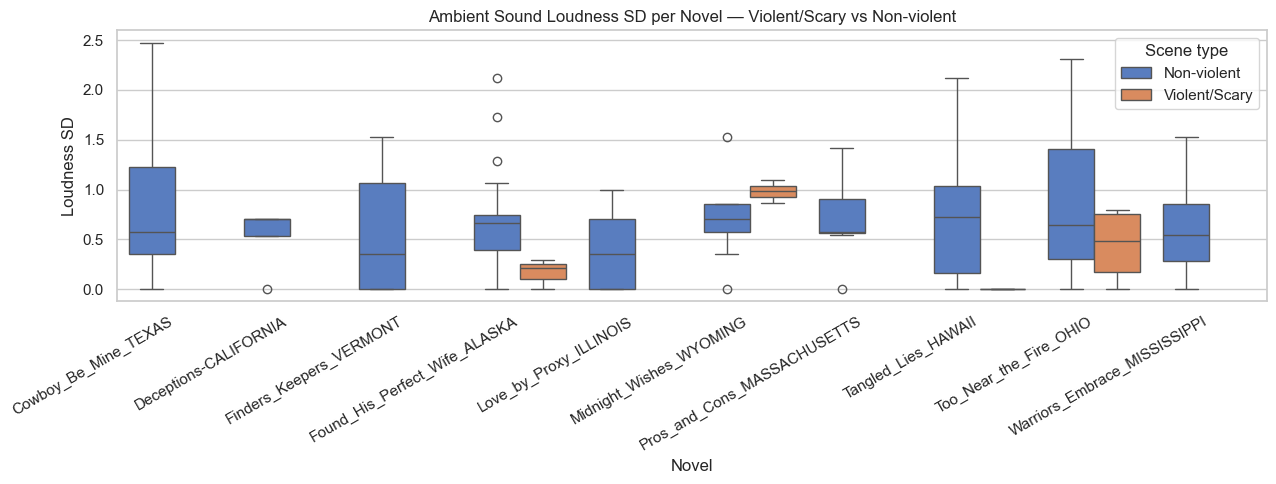

Saved boxplot_amb_per_novel_violence.png


In [ ]:
# ── 8e. Per-novel boxplot of char_std ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
novel_order = sorted(plot_df["novel_id"].unique())
sns.boxplot(data=plot_df, x="novel_id", y="amb_std",
            hue="Scene type", order=novel_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("Ambient Sound Loudness SD per Novel — Violent/Scary vs Non-violent")
ax.set_xlabel("Novel")
ax.set_ylabel("Loudness SD")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "202605_boxplot_amb_per_novel_violence.png", dpi=150)
plt.show()
print("Saved boxplot_amb_per_novel_violence.png")

## 9. Sensitivity check: strong-only violent/scary scenes

Re-runs the Mann-Whitney test restricting the violent class to **score 2 (strong)** only, leaving score 1 (weak) out of both groups. This isolates whether the effect is driven by explicitly violent/scary scenes specifically.


In [ ]:
strong_std = df_valid.loc[df_valid["violence_score"] == 2, "char_std"].dropna()
absent_std = df_valid.loc[df_valid["violence_score"] == 0, "char_std"].dropna()

print("Sensitivity check: strong (score 2) vs absent (score 0)")
print("-" * 50)
if len(strong_std) > 0 and len(absent_std) > 0:
    u2, p2 = mannwhitneyu(strong_std, absent_std, alternative="greater")
    r2     = 1 - (2 * u2) / (len(strong_std) * len(absent_std))
    print(f"Strong  n={len(strong_std)},  mean std = {strong_std.mean():.3f}")
    print(f"Absent  n={len(absent_std)},  mean std = {absent_std.mean():.3f}")
    print(f"U = {u2:.1f},  p = {p2:.4f},  rank-biserial r = {r2:.3f}")
    print(f"→ {'Significant' if p2 < 0.05 else 'Not significant'} at α = 0.05")
else:
    print("Insufficient data for one or both groups.")

Sensitivity check: strong (score 2) vs absent (score 0)
--------------------------------------------------
Strong  n=19,  mean std = 0.883
Absent  n=556,  mean std = 0.511
U = 7967.5,  p = 0.0001,  rank-biserial r = -0.508
→ Significant at α = 0.05


End of Notebook. Version from 20260508.